In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/reviews.csv")

# Display basic information
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


Dataset Shape: (7583, 2)

Columns:
['review', 'sentiment']

First 5 rows:


,review,sentiment
0,The movie was a complete snoozefest. I regret...,negative
1,"Seriously, the worst venue I've ever been to. ...",negative
2,"This event was so poorly organized, it was a j...",negative
3,What a disaster of a movie! The acting was aw...,negative
4,I wouldn't recommend this venue to my worst en...,negative


In [2]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 7583 entries, 0 to 7582
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     7583 non-null   str  
 1   sentiment  7583 non-null   str  
dtypes: str(2)
memory usage: 767.5 KB


In [3]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
review       0
sentiment    0
dtype: int64


In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [5]:
print("Sentiment Distribution:")
print(df["sentiment"].value_counts())

Sentiment Distribution:
sentiment
positive    3256
negative    2289
neutral     2038
Name: count, dtype: int64


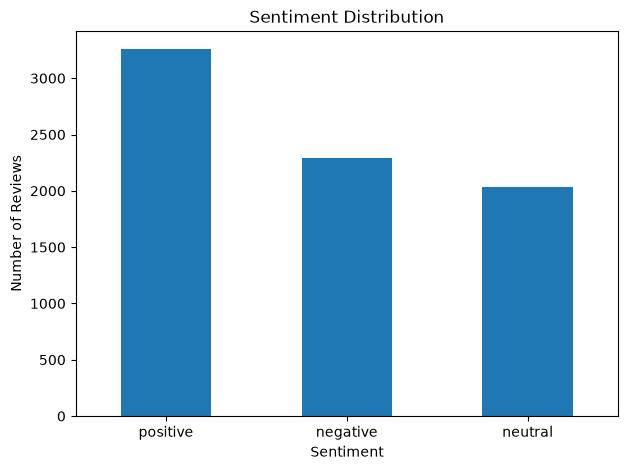

In [6]:
import matplotlib.pyplot as plt

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [7]:
df["review_length"] = df["review"].astype(str).str.len()

print(df["review_length"].describe())

count    7583.000000
mean       79.738758
std        34.608820
min         6.000000
25%        52.000000
50%        81.000000
75%       105.000000
max       304.000000
Name: review_length, dtype: float64


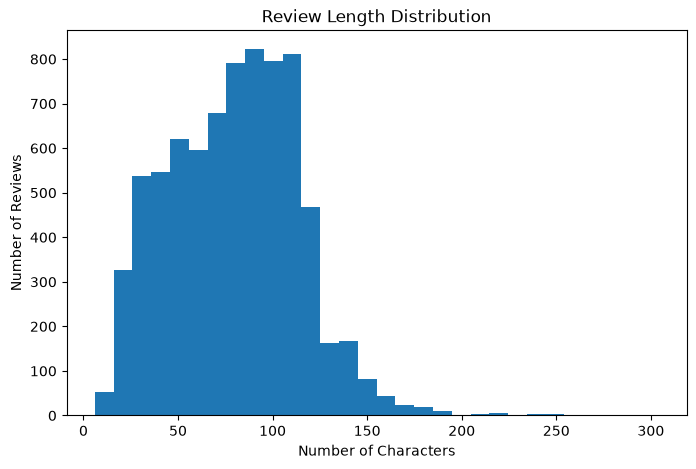

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df["review_length"], bins=30)

plt.title("Review Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Reviews")

plt.show()

In [9]:
df["word_count"] = df["review"].astype(str).str.split().str.len()

print(df["word_count"].describe())

count    7583.000000
mean       13.574047
std         6.032294
min         1.000000
25%         9.000000
50%        14.000000
75%        17.000000
max        50.000000
Name: word_count, dtype: float64


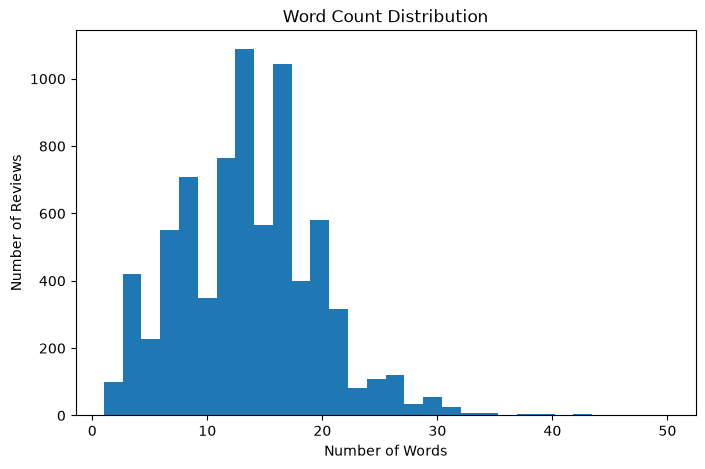

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["word_count"], bins=30)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

In [11]:
display(df[df["sentiment"] == "positive"][["review", "sentiment"]].head(5))

,review,sentiment
663,This concert was absolutely incredible! The en...,positive
664,"I loved this movie! The acting was superb, the...",positive
665,What a fantastic product! It's exactly what I ...,positive
666,"The venue was amazing! Great sound, comfortab...",positive
667,This event was so much fun! I met some great ...,positive


In [12]:
display(df[df["sentiment"] == "negative"][["review", "sentiment"]].head(5))

,review,sentiment
0,The movie was a complete snoozefest. I regret...,negative
1,"Seriously, the worst venue I've ever been to. ...",negative
2,"This event was so poorly organized, it was a j...",negative
3,What a disaster of a movie! The acting was aw...,negative
4,I wouldn't recommend this venue to my worst en...,negative


In [13]:
display(df[df["sentiment"] == "neutral"][["review", "sentiment"]].head(5))

,review,sentiment
153,"The product was okay, nothing special. It did ...",neutral
154,"The movie was alright. It wasn't amazing, but...",neutral
155,The event was decent. Could have been better ...,neutral
156,The venue was average. Nothing to write home ...,neutral
157,"It was a pretty standard product. Not bad, no...",neutral


In [14]:
import re

url_count = df["review"].astype(str).str.contains(
    r"https?://|www\.",
    regex=True,
    case=False
).sum()

print("Reviews containing URLs:", url_count)

Reviews containing URLs: 0


In [15]:
html_count = df["review"].astype(str).str.contains(
    r"<[^>]+>",
    regex=True
).sum()

print("Reviews containing HTML:", html_count)

Reviews containing HTML: 0


In [16]:
display(df[df["review"].astype(str).str.contains(
    r"[^\x00-\x7F]",
    regex=True
)][["review", "sentiment"]].head(10))

,review,sentiment
18,The movie was predictable and cliché. I've se...,negative
1021,I'm furious with 'SpeedyShipping' – my order w...,negative
1040,I'm absolutely livid with 'ReliableRentals' – ...,negative
2182,I’m impressed with the quality.,positive
2186,I can’t recommend it enough!,positive
2188,I’m thrilled with the results.,positive
2193,I’m very pleased with my choice.,positive
2198,I’m really happy with how it works.,positive
2201,It’s everything I hoped for.,positive
2203,I can’t believe how good it is.,positive
